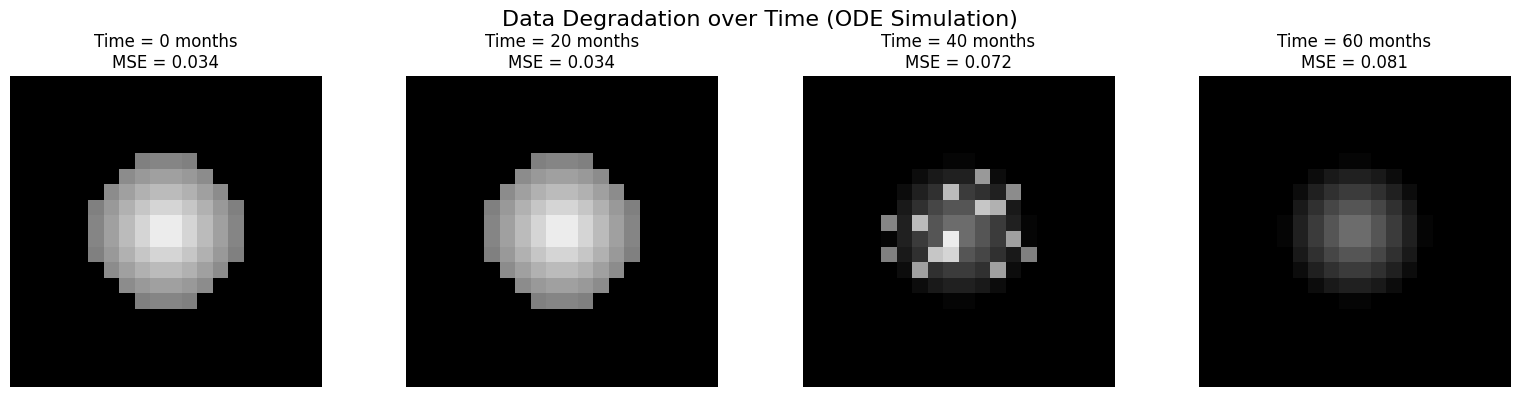

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

N_pixels = 400
t_span = (0, 60)
T_amb = 25

# Generated data that will be degraded (an image)
x_grid, y_grid = np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))
I_orig = np.clip(1 - np.sqrt(x_grid**2 + y_grid**2), 0, 1)

# Initial state vector x(0): MSB charge values based on image intensity
x0 = np.where(I_orig.flatten() > 0.5, 1.0, 0.1)

def ssd_degradation(t, x):
    k_tunnel = 0.005
    W_t = 0.001 * t
    
    # Simulate a hot summer causing a thermal spike at t=50
    T_op = 25 + 15 * np.exp(-0.1 * (t - 50)**2)
    thermal_stress = 0.002 * (T_op - T_amb)
    
    a_ii = -(k_tunnel + W_t + thermal_stress)
    
    # f_i factor (Random cosmic radiation / alpha particle hits)
    # 0.1% chance per timestep to suffer a massive charge drop
    f = -0.5 * (np.random.rand(N_pixels) < 0.001).astype(float)
    
    return (np.eye(N_pixels) * a_ii).dot(x) * x + f

sol = solve_ivp(ssd_degradation, t_span, x0, t_eval=np.linspace(0, 60, 4))
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Data Degradation over Time (ODE Simulation)", fontsize=16)

threshold = 0.5 # Threshold where the MSB flips

for i, t_val in enumerate(sol.t):
    # Convert continuous ODE charge state back to discrete binary hardware logic
    x_state = sol.y[:, i]
    # If charge > threshold, MSB is intact. If it drops, bit flips to 0.
    MSB_intact = x_state > threshold
    
    # Reconstruct degraded image
    # If MSB flips, intensity drops by half (simulating 8-bit logic)
    I_deg = np.where(MSB_intact, I_orig.flatten(), I_orig.flatten() - 0.5)
    I_deg = np.clip(I_deg, 0, 1).reshape((20, 20))
    
    # Calculate MSE
    mse = np.mean((I_orig - I_deg)**2)
    
    ax = axes[i]
    ax.imshow(I_deg, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Time = {t_val:.0f} months\nMSE = {mse:.3f}")
    ax.axis('off')

plt.tight_layout()
plt.show()